# Week 4 Day 2 – Time Series Forecasting

## Learning objectives
- Understand trend, seasonality, and noise
- Decompose a time series and test stationarity
- Use chronological train/test splits
- Build baseline, statistical, Prophet, ML, and deep learning forecasts
- Compare models with MAE, RMSE, and MAPE

## Section 1 — Introduction to Time Series

In time series data, **order matters**. Past values can influence future values (**autocorrelation**).

- **Trend:** long-term increase or decrease
- **Seasonality:** repeating pattern (for example monthly)
- **Noise / residual:** random variation

> **Never use random train/test split** for forecasting. Future data must not leak into training.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.ar_model import AutoReg

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

%matplotlib inline
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
RUN_DEEP_LEARNING = True  # set False on slow machines
TEST_RATIO = 0.2
SEASONAL_PERIOD = 12

try:
    from xgboost import XGBRegressor
except ImportError:
    XGBRegressor = None
    print('xgboost not installed — using HistGradientBoostingRegressor as fallback.')

try:
    from prophet import Prophet
except ImportError:
    Prophet = None
    print('prophet not installed — optional section will be skipped. Install with: pip install prophet')

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False
    print('PyTorch not installed — deep learning section will be skipped.')

xgboost not installed — using HistGradientBoostingRegressor as fallback.
prophet not installed — optional section will be skipped. Install with: pip install prophet


### Shared path helper

In [2]:
from pathlib import Path

def find_repo_root():
    cwd = Path.cwd().resolve()
    for candidate in [cwd] + list(cwd.parents):
        if (candidate / "requirements.txt").exists() and (candidate / "data").exists():
            return candidate
    return cwd

REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / "data" / "week4"
FIGURES_DIR = REPO_ROOT / "Week_04_Unsupervised_Learning_Time_Series_and_Reporting" / "figures"
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CUSTOMER_CSV = DATA_DIR / "week4_customer_segmentation.csv"
AIRPASSENGERS_CSV = DATA_DIR / "week4_air_passengers.csv"


## Section 2 — Load and Visualize Time Series

We use the classic **AirPassengers** series (embedded locally so the notebook runs offline).

In [3]:
AIRPASSENGERS_VALUES = [
    112,118,132,129,121,135,148,148,136,119,104,118,115,126,141,135,125,149,170,164,151,180,193,186,
    174,160,196,218,211,186,231,257,263,249,280,284,277,317,325,335,318,362,348,363,435,491,505,404,
    359,437,506,432,405,481,517,525,595,596,628,622,598,548,582,611,604,634,658,622,644,653,681,655,
    622,727,725,706,734,750,711,747,785,715,773,828,726,796,867,912,820,853,895,890,810,812,888,913,
    929,1045,1089,1005,1066,1072,1102,1028,1083,1114,1074,1084,1152,1178,1159,1163,1185,1154
]

def load_air_passengers():
    if AIRPASSENGERS_CSV.exists():
        df = pd.read_csv(AIRPASSENGERS_CSV, parse_dates=['date'])
    else:
        dates = pd.date_range('1949-01', periods=len(AIRPASSENGERS_VALUES), freq='MS')
        df = pd.DataFrame({'date': dates, 'passengers': AIRPASSENGERS_VALUES})
        df.to_csv(AIRPASSENGERS_CSV, index=False)
        print('Saved:', AIRPASSENGERS_CSV)
    df = df.sort_values('date').set_index('date')
    return df

ts = load_air_passengers()
y = ts['passengers'].astype(float)
display(ts.head())
print('Length:', len(y))

Saved: /Users/mehrdadjalali/Documents/SRH-Courses/Modules/Statistics and Machine Learning/Hands-on/Statistics-and-Machine-Learning/data/week4/week4_air_passengers.csv


,passengers
date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


Length: 114


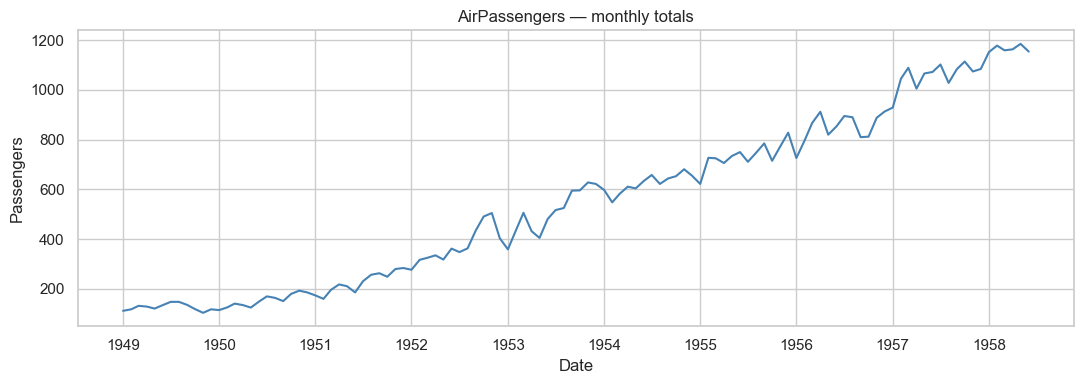

In [4]:
plt.figure(figsize=(11, 4))
plt.plot(y.index, y.values, color='steelblue')
plt.title('AirPassengers — monthly totals')
plt.xlabel('Date'); plt.ylabel('Passengers')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'day2_time_series.png', dpi=120, bbox_inches='tight')
plt.show()

## Section 3 — Time-Series Decomposition

Observed ≈ trend + seasonality + residual. Decomposition helps choose models (trend → differencing, seasonality → SARIMA/seasonal naive).

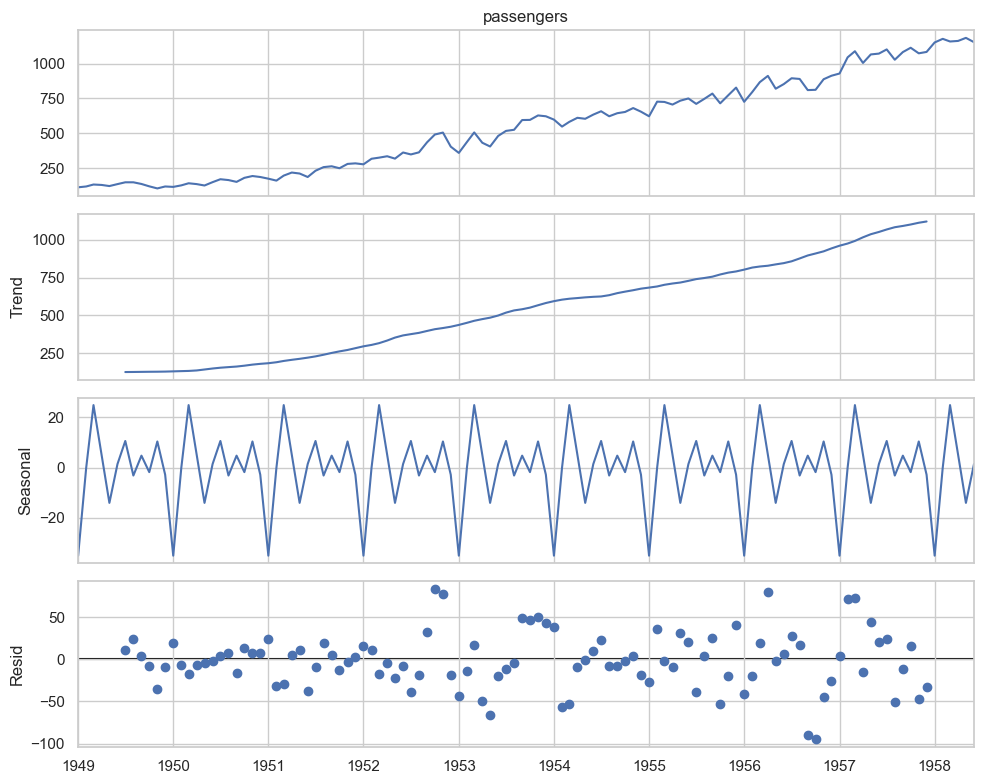

In [5]:
decomp = seasonal_decompose(y, model='additive', period=SEASONAL_PERIOD)
fig = decomp.plot()
fig.set_size_inches(10, 8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'day2_decomposition.png', dpi=120, bbox_inches='tight')
plt.show()

## Section 4 — Stationarity

A stationary series has relatively stable mean and variance (no strong trend or shifting seasonality). Many classical models assume stationarity or use differencing.

**Differencing** models changes instead of raw levels.

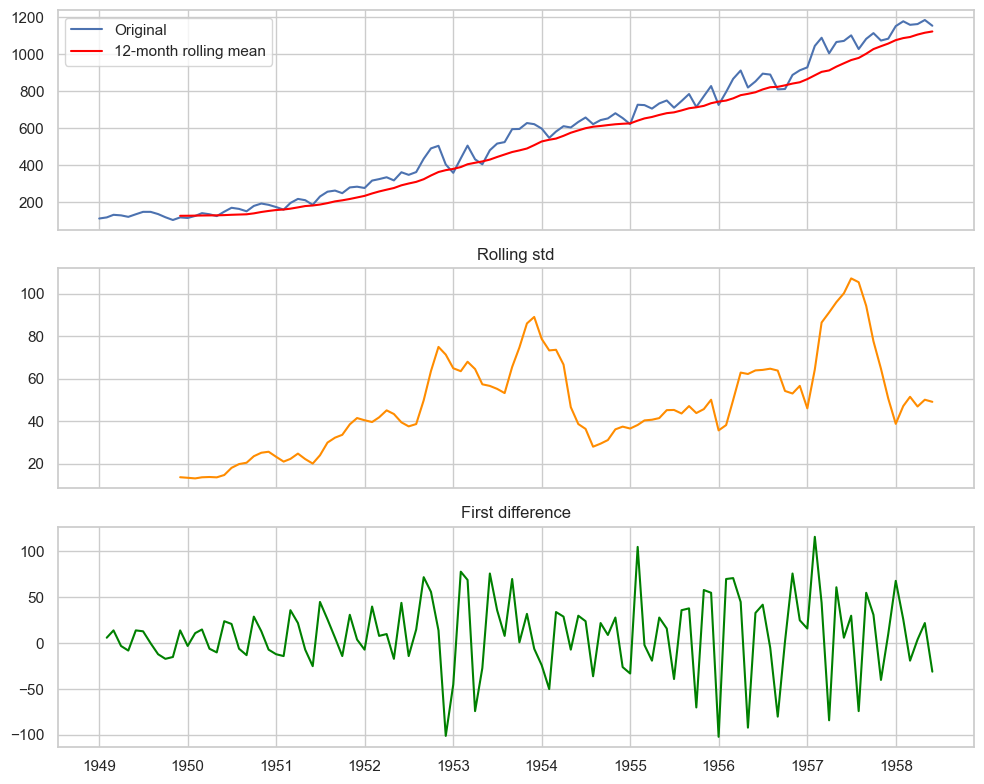

ADF statistic: 1.698, p-value: 0.9981
If p-value > 0.05, series is likely non-stationary (reject null with caution).


In [6]:
roll_mean = y.rolling(12).mean()
roll_std = y.rolling(12).std()
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
axes[0].plot(y, label='Original'); axes[0].legend()
axes[0].plot(roll_mean, color='red', label='12-month rolling mean'); axes[0].legend()
axes[1].plot(roll_std, color='darkorange'); axes[1].set_title('Rolling std')
diff1 = y.diff().dropna()
axes[2].plot(diff1, color='green'); axes[2].set_title('First difference')
plt.tight_layout(); plt.show()

adf = adfuller(y.dropna())
print(f'ADF statistic: {adf[0]:.3f}, p-value: {adf[1]:.4f}')
print('If p-value > 0.05, series is likely non-stationary (reject null with caution).')

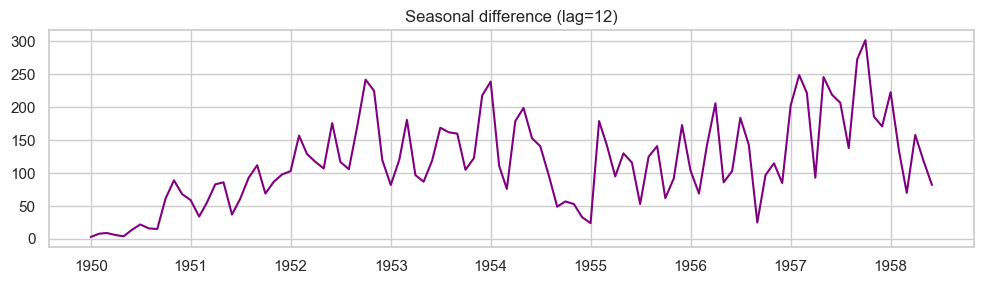

In [7]:
seasonal_diff = y.diff(SEASONAL_PERIOD).dropna()
plt.figure(figsize=(10, 3))
plt.plot(seasonal_diff, color='purple')
plt.title(f'Seasonal difference (lag={SEASONAL_PERIOD})')
plt.tight_layout(); plt.show()

## Section 5 — Time-Based Train/Test Split

Train: 1949-01-01 to 1956-07-01 | n = 91
Test : 1956-08-01 to 1958-06-01 | n = 23


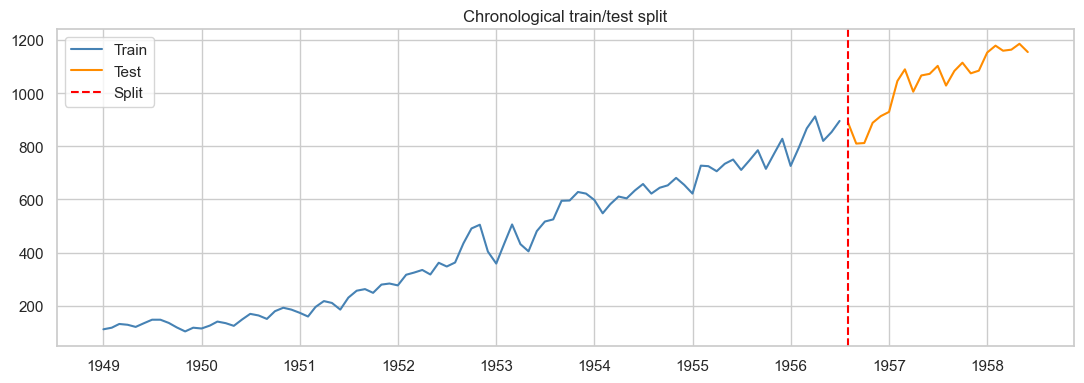

In [8]:
split_idx = int(len(y) * (1 - TEST_RATIO))
train, test = y.iloc[:split_idx], y.iloc[split_idx:]
split_date = test.index[0]
print('Train:', train.index.min().date(), 'to', train.index.max().date(), '| n =', len(train))
print('Test :', test.index.min().date(), 'to', test.index.max().date(), '| n =', len(test))

plt.figure(figsize=(11, 4))
plt.plot(train, label='Train', color='steelblue')
plt.plot(test, label='Test', color='darkorange')
plt.axvline(split_date, color='red', linestyle='--', label='Split')
plt.legend(); plt.title('Chronological train/test split')
plt.tight_layout(); plt.show()

### Data leakage warning
Do not shuffle time series rows. Do not scale or impute using statistics from the full dataset including the test period.

## Section 6 — Baseline Forecasts

Baselines are simple rules. **Complex models are useful only if they beat simple baselines.**

In [9]:
def evaluate_forecast(name, y_true, y_pred, store, extra=None):
  y_true = np.asarray(y_true, dtype=float)
  y_pred = np.asarray(y_pred, dtype=float)
  mae = mean_absolute_error(y_true, y_pred)
  rmse = np.sqrt(mean_squared_error(y_true, y_pred))
  mape = np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1e-6, None))) * 100
  row = {'Model': name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}
  if extra:
      row.update(extra)
  store.append(row)
  return row

results = []

# 1) Naive: last observed value
naive_pred = np.repeat(train.iloc[-1], len(test))
evaluate_forecast('Naive', test, naive_pred, results)

# 2) Seasonal naive: value from same month last year
seasonal_preds = []
for dt in test.index:
    lag_date = dt - pd.DateOffset(years=1)
    val = y.loc[lag_date] if lag_date in y.index else train.iloc[-1]
    seasonal_preds.append(val)
evaluate_forecast('Seasonal Naive', test, seasonal_preds, results)

# 3) Moving average of last 12 train points
ma_window = 12
ma_value = train.iloc[-ma_window:].mean()
ma_pred = np.repeat(ma_value, len(test))
evaluate_forecast('Moving Average (12)', test, ma_pred, results)

baseline_df = pd.DataFrame(results).round(3)
display(baseline_df)

,Model,MAE,RMSE,MAPE
0,Naive,163.913,186.375,15.012
1,Seasonal Naive,163.435,178.177,15.532
2,Moving Average (12),233.511,259.387,21.371


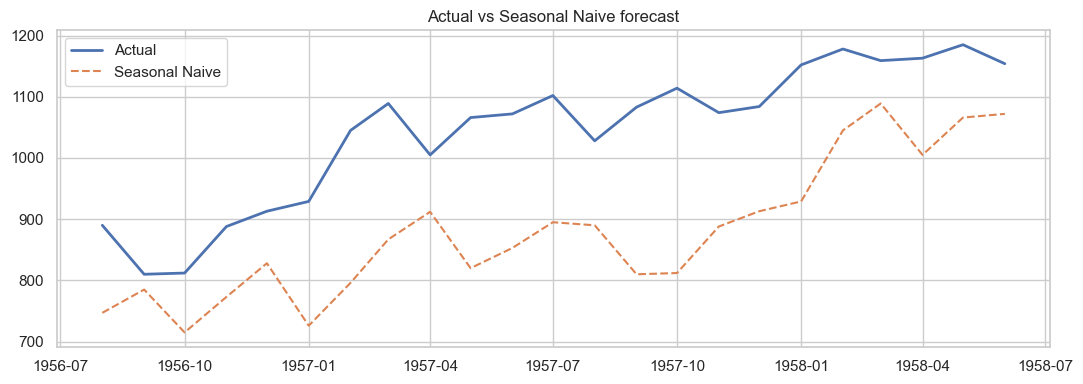

In [10]:
plt.figure(figsize=(11, 4))
plt.plot(test.index, test.values, label='Actual', linewidth=2)
plt.plot(test.index, seasonal_preds, label='Seasonal Naive', linestyle='--')
plt.title('Actual vs Seasonal Naive forecast')
plt.legend(); plt.tight_layout(); plt.show()

## Section 7 — Classical Statistical Models

In [11]:
def forecast_statistical(name, fitted, steps):
    pred = fitted.forecast(steps=steps)
    return np.asarray(pred)

stat_models = {}

In [12]:
# AR(p,0,0) via AutoReg
ar_order = 2
ar_model = AutoReg(train, lags=ar_order, old_names=False).fit()
ar_pred = forecast_statistical('AR', ar_model, len(test))
evaluate_forecast(f'AR({ar_order})', test, ar_pred, results)
stat_models['AR'] = ar_model

/Users/mehrdadjalali/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [13]:
# MA(0,0,q)
ma_order = 1
ma_model = ARIMA(train, order=(0, 0, ma_order)).fit()
ma_pred = forecast_statistical('MA', ma_model, len(test))
evaluate_forecast(f'MA({ma_order})', test, ma_pred, results)

/Users/mehrdadjalali/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/mehrdadjalali/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/mehrdadjalali/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


{'Model': 'MA(1)',
 'MAE': 608.715245612102,
 'RMSE': 622.0690397359431,
 'MAPE': 57.68666155229043}

In [14]:
# ARMA(p,0,q)
p, q = 2, 1
arma_model = ARIMA(train, order=(p, 0, q)).fit()
arma_pred = forecast_statistical('ARMA', arma_model, len(test))
evaluate_forecast(f'ARMA({p},{q})', test, arma_pred, results)

/Users/mehrdadjalali/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/mehrdadjalali/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/mehrdadjalali/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


{'Model': 'ARMA(2,1)',
 'MAE': 199.08091732287812,
 'RMSE': 226.80828497229427,
 'MAPE': 18.176315599648106}

/Users/mehrdadjalali/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/mehrdadjalali/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/mehrdadjalali/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


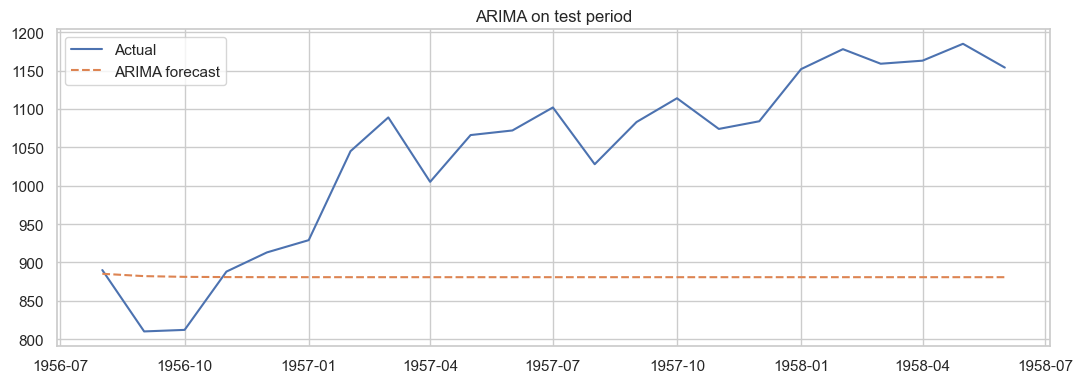

In [15]:
# ARIMA(p,d,q)
p, d, q = 1, 1, 1
arima_model = ARIMA(train, order=(p, d, q)).fit()
arima_pred = forecast_statistical('ARIMA', arima_model, len(test))
evaluate_forecast(f'ARIMA({p},{d},{q})', test, arima_pred, results)

plt.figure(figsize=(11, 4))
plt.plot(test.index, test.values, label='Actual')
plt.plot(test.index, arima_pred, label='ARIMA forecast', linestyle='--')
plt.legend(); plt.title('ARIMA on test period'); plt.tight_layout(); plt.show()

/Users/mehrdadjalali/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/mehrdadjalali/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


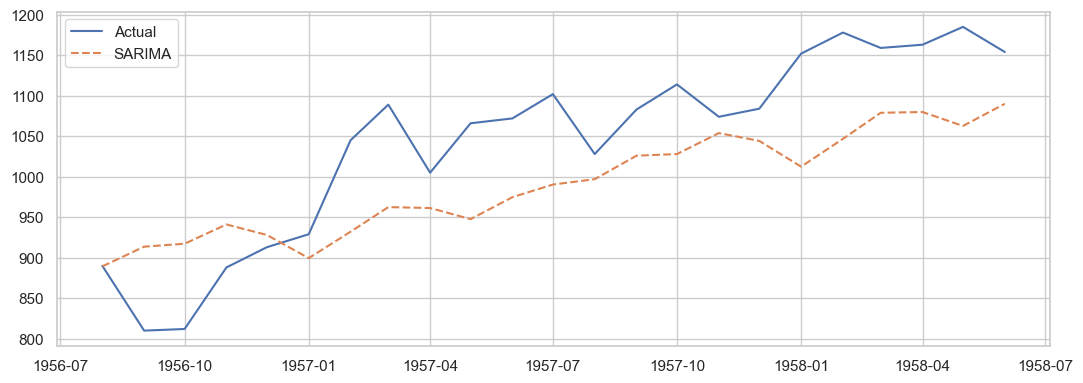

In [16]:
# SARIMA
order = (1, 1, 1)
seasonal_order = (1, 1, 1, SEASONAL_PERIOD)
sarima_model = SARIMAX(train, order=order, seasonal_order=seasonal_order,
                       enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
sarima_pred = sarima_model.forecast(len(test))
evaluate_forecast(f'SARIMA{order}x{seasonal_order}', test, sarima_pred, results)

plt.figure(figsize=(11, 4))
plt.plot(test.index, test.values, label='Actual')
plt.plot(test.index, sarima_pred, label='SARIMA', linestyle='--')
plt.legend(); plt.tight_layout(); plt.show()

## Section 8 — Prophet (optional)

Prophet is useful for business series with trend, seasonality, holidays, missing values, and outliers.

Install (optional): `pip install prophet`

In [17]:
if Prophet is not None:
    prophet_train = train.reset_index().rename(columns={'date': 'ds', 'passengers': 'y'})
    m_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    m_prophet.fit(prophet_train)
    future = pd.DataFrame({'ds': test.index})
    fcst = m_prophet.predict(future)
    prophet_pred = fcst['yhat'].values
    evaluate_forecast('Prophet', test, prophet_pred, results)
    fig = m_prophet.plot(fcst)
    plt.tight_layout(); plt.show()
else:
    print('Skipping Prophet — package not available.')

Skipping Prophet — package not available.


## Section 9 — Machine Learning Forecasting with Feature Engineering

Tree models do not see time order automatically. We create **lags**, **rolling** stats, and **calendar** features.

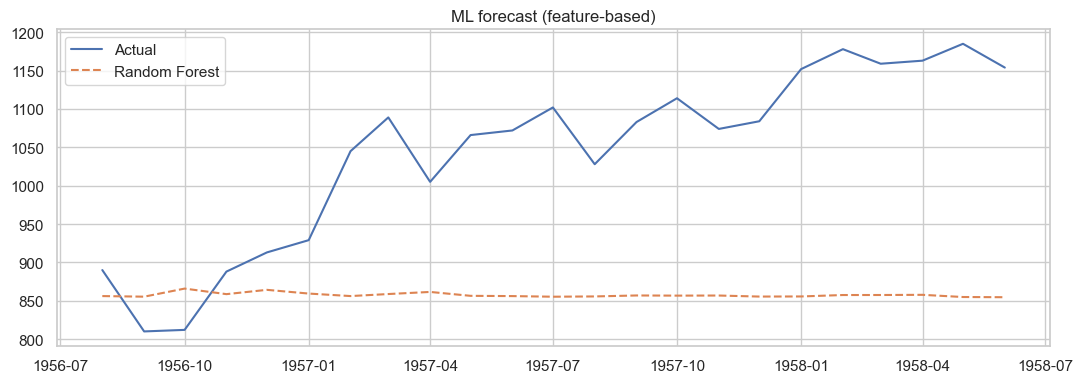

In [18]:
def make_supervised_frame(series, max_lag=12):
    df = pd.DataFrame({'y': series})
    for lag in [1, 2, max_lag]:
        df[f'lag_{lag}'] = df['y'].shift(lag)
    df['roll_mean_3'] = df['y'].shift(1).rolling(3).mean()
    df['roll_std_3'] = df['y'].shift(1).rolling(3).std()
    df['month'] = df.index.month
    df['quarter'] = df.index.quarter
    df['year'] = df.index.year
    df['time_idx'] = np.arange(len(df))
    return df.dropna()

full_feat = make_supervised_frame(y, max_lag=12)
train_feat = full_feat.loc[full_feat.index <= train.index.max()]
test_feat = full_feat.loc[full_feat.index.isin(test.index)]
feature_cols = [c for c in full_feat.columns if c != 'y']
X_tr, y_tr = train_feat[feature_cols], train_feat['y']
X_te, y_te = test_feat[feature_cols], test_feat['y']

rf = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
rf.fit(X_tr, y_tr)
rf_pred = rf.predict(X_te)
evaluate_forecast('Random Forest', y_te, rf_pred, results)

if XGBRegressor is not None:
    xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, random_state=RANDOM_STATE, verbosity=0)
    xgb.fit(X_tr, y_tr)
    xgb_pred = xgb.predict(X_te)
    evaluate_forecast('XGBoost', y_te, xgb_pred, results)
else:
    hgb = HistGradientBoostingRegressor(random_state=RANDOM_STATE)
    hgb.fit(X_tr, y_tr)
    hgb_pred = hgb.predict(X_te)
    evaluate_forecast('HistGradientBoosting (XGB fallback)', y_te, hgb_pred, results)

plt.figure(figsize=(11, 4))
plt.plot(y_te.index, y_te.values, label='Actual')
plt.plot(y_te.index, rf_pred, label='Random Forest', linestyle='--')
plt.legend(); plt.title('ML forecast (feature-based)'); plt.tight_layout(); plt.show()

## Section 10 — Deep Learning Forecasting (optional)

- **LSTM:** captures longer dependencies; needs more data and compute
- **GRU:** simpler, often a good compromise
- **Transformer:** attention over past steps; powerful but data-hungry

Set `RUN_DEEP_LEARNING = False` if training is too slow.

In [19]:
dl_predictions = {}

if RUN_DEEP_LEARNING and TORCH_AVAILABLE:
    from sklearn.preprocessing import MinMaxScaler

    def make_sequences(values, seq_len):
        X, y_seq = [], []
        for i in range(seq_len, len(values)):
            X.append(values[i-seq_len:i])
            y_seq.append(values[i])
        return np.array(X), np.array(y_seq)

    seq_len = 12
    scaler_dl = MinMaxScaler()
    scaled = scaler_dl.fit_transform(y.values.reshape(-1, 1)).ravel()
    X_all, y_all = make_sequences(scaled, seq_len)
    dates_all = y.index[seq_len:]
    train_mask = dates_all <= train.index.max()
    X_dl_train, y_dl_train = X_all[train_mask], y_all[train_mask]
    X_dl_test, y_dl_test = X_all[~train_mask], y_all[~train_mask]
    test_dates_dl = dates_all[~train_mask]

    class LSTMReg(nn.Module):
        def __init__(self, hidden=32):
            super().__init__()
            self.rnn = nn.LSTM(1, hidden, batch_first=True)
            self.fc = nn.Linear(hidden, 1)
        def forward(self, x):
            out, _ = self.rnn(x)
            return self.fc(out[:, -1, :]).squeeze(-1)

    class GRUReg(nn.Module):
        def __init__(self, hidden=32):
            super().__init__()
            self.rnn = nn.GRU(1, hidden, batch_first=True)
            self.fc = nn.Linear(hidden, 1)
        def forward(self, x):
            out, _ = self.rnn(x)
            return self.fc(out[:, -1, :]).squeeze(-1)

    class SimpleTransformerReg(nn.Module):
        def __init__(self, seq_len, d_model=16):
            super().__init__()
            self.input_proj = nn.Linear(1, d_model)
            layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=2, batch_first=True, dim_feedforward=32)
            self.encoder = nn.TransformerEncoder(layer, num_layers=1)
            self.fc = nn.Linear(d_model, 1)
        def forward(self, x):
            h = self.input_proj(x)
            h = self.encoder(h)
            return self.fc(h[:, -1, :]).squeeze(-1)

    def train_torch_model(model_cls, label, epochs=15, **kwargs):
        torch.manual_seed(RANDOM_STATE)
        model = model_cls(**kwargs)
        opt = torch.optim.Adam(model.parameters(), lr=0.01)
        loss_fn = nn.MSELoss()
        X_t = torch.tensor(X_dl_train, dtype=torch.float32).unsqueeze(-1)
        y_t = torch.tensor(y_dl_train, dtype=torch.float32)
        loader = DataLoader(TensorDataset(X_t, y_t), batch_size=16, shuffle=True)
        model.train()
        for _ in range(epochs):
            for xb, yb in loader:
                opt.zero_grad()
                pred = model(xb)
                loss = loss_fn(pred, yb)
                loss.backward()
                opt.step()
        model.eval()
        with torch.no_grad():
            pred_scaled = model(torch.tensor(X_dl_test, dtype=torch.float32).unsqueeze(-1)).numpy()
        pred = scaler_dl.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()
        y_true = scaler_dl.inverse_transform(y_dl_test.reshape(-1, 1)).ravel()
        return y_true, pred

    dl_specs = [
        (LSTMReg, 'LSTM', {}),
        (GRUReg, 'GRU', {}),
        (SimpleTransformerReg, 'Transformer', {'seq_len': seq_len}),
    ]
    for cls, label, kw in dl_specs:
        y_true_dl, pred_dl = train_torch_model(cls, label, epochs=12, **kw)
        evaluate_forecast(label, y_true_dl, pred_dl, results)
        dl_predictions[label] = (test_dates_dl, y_true_dl, pred_dl)
        print(f'{label} trained.')
else:
    print('Deep learning skipped (RUN_DEEP_LEARNING=False or PyTorch missing).')

LSTM trained.
GRU trained.


Transformer trained.


## Section 11 — Model Comparison Table

In [20]:
comparison = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
display(comparison.round(3))
comparison.to_csv(DATA_DIR / 'week4_forecast_model_comparison.csv', index=False)
print('Saved comparison table to', DATA_DIR / 'week4_forecast_model_comparison.csv')

,Model,MAE,RMSE,MAPE
0,GRU,36.942,49.306,3.686
1,LSTM,36.282,49.525,3.674
2,AR(2),65.414,73.435,6.272
3,"SARIMA(1, 1, 1)x(1, 1, 1, 12)",77.035,87.228,7.323
4,Transformer,113.430,124.069,10.494
5,Seasonal Naive,163.435,178.177,15.532
6,Naive,163.913,186.375,15.012
7,"ARIMA(1,1,1)",174.546,197.947,15.962
8,Random Forest,194.380,218.172,17.780
9,"ARMA(2,1)",199.081,226.808,18.176


Saved comparison table to /Users/mehrdadjalali/Documents/SRH-Courses/Modules/Statistics and Machine Learning/Hands-on/Statistics-and-Machine-Learning/data/week4/week4_forecast_model_comparison.csv


### Interpretation prompts
- Which model had the lowest RMSE?
- Did complex models beat seasonal naive?
- Which model is most interpretable? Most practical for deployment?

### Common mistakes / warnings
- Random train/test split on time series
- Fitting scalers on train+test together
- Comparing models on different test lengths without noticing
- Over-interpreting small test-set improvements

## Section 12 — Student Exercise

1. Use a chronological train/test split.
2. Implement at least one baseline.
3. Fit at least one statistical model.
4. Fit at least one ML model.
5. Compare MAE / RMSE / MAPE.
6. Choose a model and justify interpretability, stability, and practicality.

### Reflection questions
- When would you prefer SARIMA over XGBoost?
- What happens if trend changes after the training period?
- Why is seasonal naive strong on AirPassengers?

## Mini summary
- Respect time order in splits and feature engineering.
- Always benchmark against naive baselines.
- Classical models capture autocorrelation structure; ML needs explicit features.
- Deep learning is optional and data-hungry.

## Final task checklist
- [ ] Time-based split plotted
- [ ] At least 3 baselines / statistical / ML models compared
- [ ] Metrics table saved
- [ ] Model choice explained
- [ ] Limitations noted

In [21]:
print('Week 4 Day 2 Time Series Forecasting completed successfully.')

Week 4 Day 2 Time Series Forecasting completed successfully.
